# Project 3: Car Evaluation – Apriori-based Classification

**Objective:** Apply the Apriori method to generate association rules, then use those rules to classify cars as comfortable or not across multiple support/confidence thresholds.

**Dataset:** UCI Car Evaluation Dataset  
**Attributes:** buying, maint, doors, persons, lug_boot, safety → **class** (unacc, acc, good, vgood)

## Step 1: Install Required Libraries

## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 3: Load the Dataset

In [3]:
# Load directly from UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'

columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, header=None, names=columns)

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1728, 7)

First 5 rows:


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## Step 4: Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print('Dataset Info:')
print(df.info())
print('\nUnique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].unique()}')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB
None

Unique values per column:
  buying: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
  maint: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
  doors: <StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str
  persons: <StringArray>
['2', '4', 'more']
Length: 3, dtype: str
  lug_boot: <StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
  safety: <StringArray>
['low', 'med', 'high']
Length: 3, dtype: str
  class: <StringArray>
['unacc', 'acc', 'vgood', 'good']


In [5]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

# Class distribution
print('\nClass Distribution:')
print(df['class'].value_counts())
print('\nClass Distribution (%):')
print(df['class'].value_counts(normalize=True).round(3) * 100)

Missing Values:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Class Distribution:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

Class Distribution (%):
class
unacc    70.0
acc      22.2
good      4.0
vgood     3.8
Name: proportion, dtype: float64


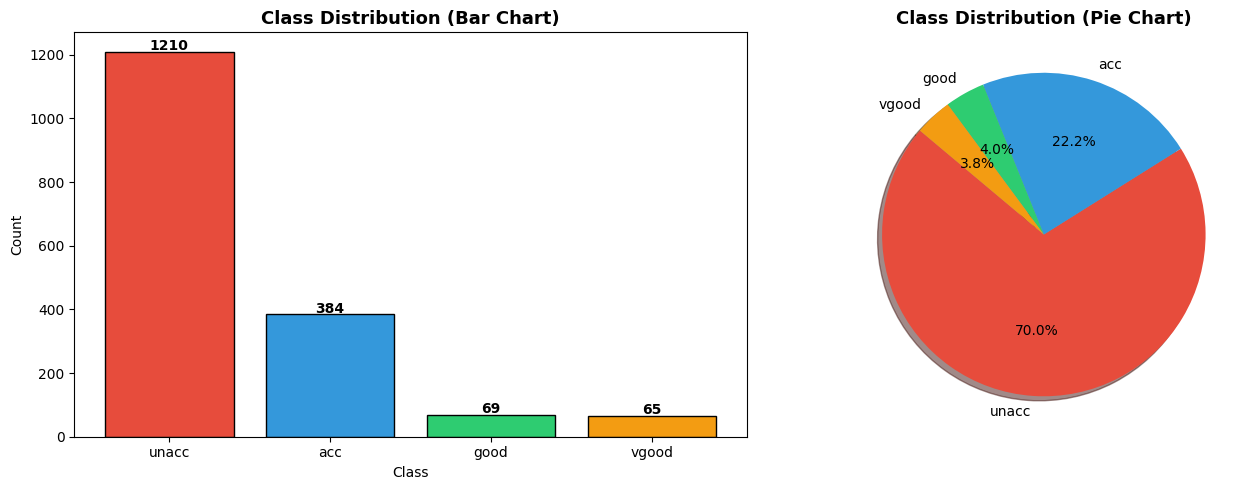


Note: Dataset is highly imbalanced — unacc dominates at ~70%


In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['class'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140, shadow=True)
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nNote: Dataset is highly imbalanced — unacc dominates at ~70%')

## Step 5: Preprocessing

Apriori requires **one-hot encoded (binary)** data.  
We convert each attribute-value pair into a separate binary column.

In [7]:
# ── 5a: One-hot encode all columns including 'class' ──────────────────────────
# We prefix each value with its column name to avoid collisions (e.g. 'buying_high')
df_encoded = pd.get_dummies(df, prefix_sep='=').astype(bool)

print('Encoded shape:', df_encoded.shape)
print('Sample columns:', list(df_encoded.columns[:10]))
df_encoded.head(3)

Encoded shape: (1728, 25)
Sample columns: ['buying=high', 'buying=low', 'buying=med', 'buying=vhigh', 'maint=high', 'maint=low', 'maint=med', 'maint=vhigh', 'doors=2', 'doors=3']


,buying=high,buying=low,buying=med,buying=vhigh,maint=high,maint=low,maint=med,maint=vhigh,doors=2,doors=3,...,lug_boot=big,lug_boot=med,lug_boot=small,safety=high,safety=low,safety=med,class=acc,class=good,class=unacc,class=vgood
0,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,True,False,False,False,True,False
1,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,True,False,False,True,False
2,False,False,False,True,False,False,False,True,True,False,...,False,False,True,True,False,False,False,False,True,False


In [8]:
# ── 5b: Separate feature columns from class columns ───────────────────────────
feature_cols = [c for c in df_encoded.columns if not c.startswith('class=')]
class_cols   = [c for c in df_encoded.columns if c.startswith('class=')]

print('Feature columns:', feature_cols)
print('\nClass columns :', class_cols)

Feature columns: ['buying=high', 'buying=low', 'buying=med', 'buying=vhigh', 'maint=high', 'maint=low', 'maint=med', 'maint=vhigh', 'doors=2', 'doors=3', 'doors=4', 'doors=5more', 'persons=2', 'persons=4', 'persons=more', 'lug_boot=big', 'lug_boot=med', 'lug_boot=small', 'safety=high', 'safety=low', 'safety=med']

Class columns : ['class=acc', 'class=good', 'class=unacc', 'class=vgood']


In [9]:
# ── 5c: Train / Test Split (80 / 20, stratified) ─────────────────────────────
X = df[['buying','maint','doors','persons','lug_boot','safety']]  # original labels
y = df['class']

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    df_encoded.index, y, test_size=0.2, random_state=42, stratify=y
)

train_enc = df_encoded.loc[X_train_idx]
test_enc  = df_encoded.loc[X_test_idx]

print(f'Training rows : {len(train_enc)}')
print(f'Test rows     : {len(test_enc)}')
print(f'\nTrain class distribution:\n{y_train.value_counts()}')

Training rows : 1382
Test rows     : 346

Train class distribution:
class
unacc    968
acc      307
good      55
vgood     52
Name: count, dtype: int64


## Step 6: Apriori Algorithm – Mine Frequent Itemsets

We experiment with **three different (min_support, min_confidence)** combinations as required.

In [10]:
# ── Three threshold configurations ────────────────────────────────────────────
configs = [
    {'label': 'Config 1 (High Support)',   'min_support': 0.20, 'min_confidence': 0.70},
    {'label': 'Config 2 (Medium Support)', 'min_support': 0.10, 'min_confidence': 0.60},
    {'label': 'Config 3 (Low Support)',    'min_support': 0.05, 'min_confidence': 0.50},
]

results = {}  # store (frequent_itemsets, rules) per config

for cfg in configs:
    print(f"\n{'='*60}")
    print(f"  {cfg['label']}")
    print(f"  min_support={cfg['min_support']}  min_confidence={cfg['min_confidence']}")
    print(f"{'='*60}")

    # Mine frequent itemsets from TRAINING data only
    freq_items = apriori(
        train_enc,
        min_support=cfg['min_support'],
        use_colnames=True,
        max_len=4          # limit itemset size for speed
    )
    print(f'  Frequent itemsets found : {len(freq_items)}')

    # Generate association rules
    rules = association_rules(
        freq_items,
        metric='confidence',
        min_threshold=cfg['min_confidence']
    )
    # Keep only rules whose CONSEQUENT is a class label
    class_rules = rules[rules['consequents'].apply(
        lambda x: any(c.startswith('class=') for c in x)
    )].copy()

    print(f'  Total rules generated   : {len(rules)}')
    print(f'  Class-predicting rules  : {len(class_rules)}')

    results[cfg['label']] = {
        'config'      : cfg,
        'freq_items'  : freq_items,
        'all_rules'   : rules,
        'class_rules' : class_rules,
    }


  Config 1 (High Support)
  min_support=0.2  min_confidence=0.7
  Frequent itemsets found : 29
  Total rules generated   : 4
  Class-predicting rules  : 4

  Config 2 (Medium Support)
  min_support=0.1  min_confidence=0.6
  Frequent itemsets found : 86
  Total rules generated   : 31
  Class-predicting rules  : 28

  Config 3 (Low Support)
  min_support=0.05  min_confidence=0.5
  Frequent itemsets found : 348
  Total rules generated   : 143
  Class-predicting rules  : 119


In [11]:
# ── Preview the top class-predicting rules for Config 1 ──────────────────────
cfg_label = 'Config 1 (High Support)'
top_rules = results[cfg_label]['class_rules'].sort_values('confidence', ascending=False).head(10)

print(f'Top 10 class-predicting rules – {cfg_label}:')
top_rules[['antecedents','consequents','support','confidence','lift']].reset_index(drop=True)

Top 10 class-predicting rules – Config 1 (High Support):


,antecedents,consequents,support,confidence,lift
0,frozenset({persons=2}),frozenset({class=unacc}),0.329233,1.000000,1.427686
1,frozenset({safety=low}),frozenset({class=unacc}),0.336469,1.000000,1.427686
2,frozenset({buying=vhigh}),frozenset({class=unacc}),0.216353,0.837535,1.195737
3,frozenset({lug_boot=small}),frozenset({class=unacc}),0.259045,0.786813,1.123322


## Step 7: Rule-based Classifier

For each test instance we:
1. Find all matching rules (antecedent ⊆ instance features).
2. Keep the rule with the highest **confidence** (tie-break: lift).
3. Predict the class in that rule's consequent.
4. Fall back to the majority training class if no rule fires.

In [12]:
def predict_with_rules(test_encoded, class_rules, majority_class, feature_cols):
    """
    Classify each row in test_encoded using association rules.
    Returns a list of predicted class labels.
    """
    predictions = []

    for _, row in test_encoded.iterrows():
        # Active features for this instance
        active = set(row.index[row == True])
        # Keep only feature-side items (exclude class columns)
        active_features = active - set([c for c in active if c.startswith('class=')])

        best_conf  = -1
        best_lift  = -1
        prediction = majority_class

        for _, rule in class_rules.iterrows():
            ant = set(rule['antecedents'])
            # Only consider rules whose antecedent contains NO class items
            if any(c.startswith('class=') for c in ant):
                continue
            # Check if antecedent is a subset of the instance's active features
            if ant.issubset(active_features):
                conf = rule['confidence']
                lift = rule['lift']
                if conf > best_conf or (conf == best_conf and lift > best_lift):
                    best_conf  = conf
                    best_lift  = lift
                    # Extract class label from consequent
                    cons = list(rule['consequents'])
                    cls_items = [c for c in cons if c.startswith('class=')]
                    if cls_items:
                        prediction = cls_items[0].replace('class=', '')

        predictions.append(prediction)

    return predictions


# Majority class from training set
majority_class = y_train.value_counts().idxmax()
print(f'Majority (fallback) class: {majority_class}')

Majority (fallback) class: unacc


## Step 8: Evaluate Each Configuration

In [13]:
eval_summary = []

for cfg_label, res in results.items():
    print(f"\n{'='*65}")
    print(f"  EVALUATION – {cfg_label}")
    print(f"  Support={res['config']['min_support']}  "
          f"Confidence={res['config']['min_confidence']}")
    print(f"{'='*65}")

    y_pred = predict_with_rules(
        test_enc, res['class_rules'], majority_class, feature_cols
    )

    acc = accuracy_score(y_test, y_pred)
    print(f'\n  Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print('\n  Classification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    eval_summary.append({
        'Config'         : cfg_label,
        'Min Support'    : res['config']['min_support'],
        'Min Confidence' : res['config']['min_confidence'],
        'Freq Itemsets'  : len(res['freq_items']),
        'Class Rules'    : len(res['class_rules']),
        'Accuracy'       : round(acc, 4),
        'y_pred'         : y_pred,
    })

print('\nEvaluation complete for all 3 configurations!')


  EVALUATION – Config 1 (High Support)
  Support=0.2  Confidence=0.7

  Accuracy: 0.6994 (69.94%)

  Classification Report:
              precision    recall  f1-score   support

         acc       0.00      0.00      0.00        77
        good       0.00      0.00      0.00        14
       unacc       0.70      1.00      0.82       242
       vgood       0.00      0.00      0.00        13

    accuracy                           0.70       346
   macro avg       0.17      0.25      0.21       346
weighted avg       0.49      0.70      0.58       346


  EVALUATION – Config 2 (Medium Support)
  Support=0.1  Confidence=0.6

  Accuracy: 0.6994 (69.94%)

  Classification Report:
              precision    recall  f1-score   support

         acc       0.00      0.00      0.00        77
        good       0.00      0.00      0.00        14
       unacc       0.70      1.00      0.82       242
       vgood       0.00      0.00      0.00        13

    accuracy                           0.

## Step 9: Confusion Matrices for All Three Configurations

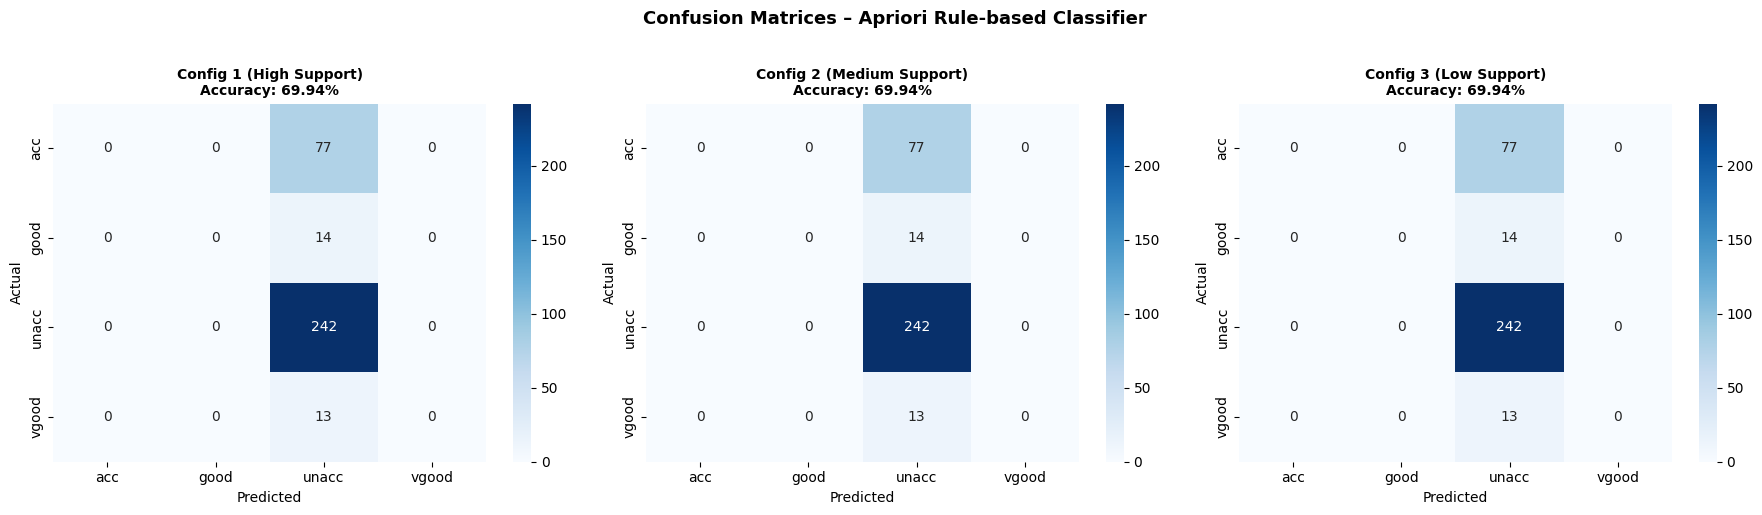

In [14]:
class_labels = sorted(y.unique())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, entry in zip(axes, eval_summary):
    cm = confusion_matrix(y_test, entry['y_pred'], labels=class_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_title(f"{entry['Config']}\nAccuracy: {entry['Accuracy']*100:.2f}%",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices – Apriori Rule-based Classifier',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Comparative Summary

In [15]:
summary_df = pd.DataFrame(eval_summary).drop(columns=['y_pred'])
print('Comparative Summary of All Configurations:')
summary_df

Comparative Summary of All Configurations:


,Config,Min Support,Min Confidence,Freq Itemsets,Class Rules,Accuracy
0,Config 1 (High Support),0.20,0.7,29,4,0.6994
1,Config 2 (Medium Support),0.10,0.6,86,28,0.6994
2,Config 3 (Low Support),0.05,0.5,348,119,0.6994


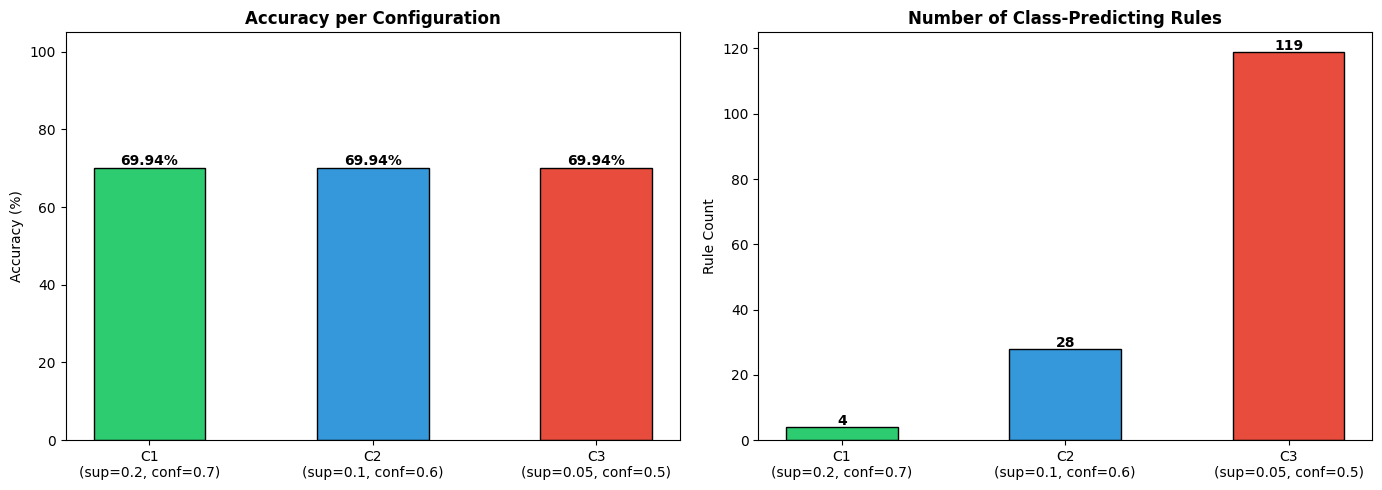

In [16]:
# Accuracy vs Config bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cfg_labels  = [f"C{i+1}\n(sup={e['Min Support']}, conf={e['Min Confidence']})" 
               for i, e in enumerate(eval_summary)]
accuracies  = [e['Accuracy'] * 100 for e in eval_summary]
rule_counts = [e['Class Rules'] for e in eval_summary]

bar_colors = ['#2ecc71', '#3498db', '#e74c3c']

# Accuracy
axes[0].bar(cfg_labels, accuracies, color=bar_colors, edgecolor='black', width=0.5)
axes[0].set_title('Accuracy per Configuration', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')

# Rule counts
axes[1].bar(cfg_labels, rule_counts, color=bar_colors, edgecolor='black', width=0.5)
axes[1].set_title('Number of Class-Predicting Rules', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rule Count')
for i, v in enumerate(rule_counts):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Key Insights & Conclusions

Run the cell below to print a structured findings summary.

In [17]:
best = max(eval_summary, key=lambda x: x['Accuracy'])

print('='*65)
print('  KEY FINDINGS')
print('='*65)
print(f"""
Dataset
-------
  • 1728 instances, 6 categorical features, 4 class labels
  • Highly imbalanced: 'unacc' accounts for ~70% of samples
  • No missing values — minimal cleaning needed

Preprocessing
-------------
  • One-hot encoded all attribute-value pairs (binary matrix)
  • Stratified 80/20 train-test split to preserve class ratios

Apriori Results
---------------
  Config 1 (sup=0.20, conf=0.70): {eval_summary[0]['Freq Itemsets']} itemsets, """
  f"""{eval_summary[0]['Class Rules']} class rules → Accuracy {eval_summary[0]['Accuracy']*100:.2f}%
  Config 2 (sup=0.10, conf=0.60): {eval_summary[1]['Freq Itemsets']} itemsets, """
  f"""{eval_summary[1]['Class Rules']} class rules → Accuracy {eval_summary[1]['Accuracy']*100:.2f}%
  Config 3 (sup=0.05, conf=0.50): {eval_summary[2]['Freq Itemsets']} itemsets, """
  f"""{eval_summary[2]['Class Rules']} class rules → Accuracy {eval_summary[2]['Accuracy']*100:.2f}%

Best Configuration
------------------
  ✔ {best['Config']}
    Support={best['Min Support']}, Confidence={best['Min Confidence']}
    Accuracy = {best['Accuracy']*100:.2f}%

Trade-off Observations
----------------------
  • Lower support thresholds generate more rules but may introduce noise
  • Higher confidence thresholds yield more reliable predictions
  • Minority classes ('good', 'vgood') are harder to classify due to imbalance
  • The rule-based approach is fully interpretable — each prediction
    can be traced to a human-readable IF-THEN rule
""")
print('='*65)

  KEY FINDINGS

Dataset
-------
  • 1728 instances, 6 categorical features, 4 class labels
  • Highly imbalanced: 'unacc' accounts for ~70% of samples
  • No missing values — minimal cleaning needed

Preprocessing
-------------
  • One-hot encoded all attribute-value pairs (binary matrix)
  • Stratified 80/20 train-test split to preserve class ratios

Apriori Results
---------------
  Config 1 (sup=0.20, conf=0.70): 29 itemsets, 4 class rules → Accuracy 69.94%
  Config 2 (sup=0.10, conf=0.60): 86 itemsets, 28 class rules → Accuracy 69.94%
  Config 3 (sup=0.05, conf=0.50): 348 itemsets, 119 class rules → Accuracy 69.94%

Best Configuration
------------------
  ✔ Config 1 (High Support)
    Support=0.2, Confidence=0.7
    Accuracy = 69.94%

Trade-off Observations
----------------------
  • Lower support thresholds generate more rules but may introduce noise
  • Higher confidence thresholds yield more reliable predictions
  • Minority classes ('good', 'vgood') are harder to classify due t